In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
# import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
# from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
# from scikeras.wrappers import KerasClassifier


### Fashion MNIST Dataset

In [2]:
fashion_train = pd.read_csv('fashion-mnist_train.csv')
fashion_train.shape


(60000, 785)

In [3]:
fashion_train


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
fashion_test = pd.read_csv('fashion-mnist_test.csv')
fashion_test.shape


(10000, 785)

In [5]:
X_train_fashion = fashion_train.drop('label',axis = 1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label',axis = 1)
y_test_fashion = fashion_test['label']


In [6]:
#Reshaping the dataset
x_train_reshape = X_train_fashion.values.reshape(-1,28,28)
x_test_reshape = X_test_fashion.values.reshape(-1,28,28)


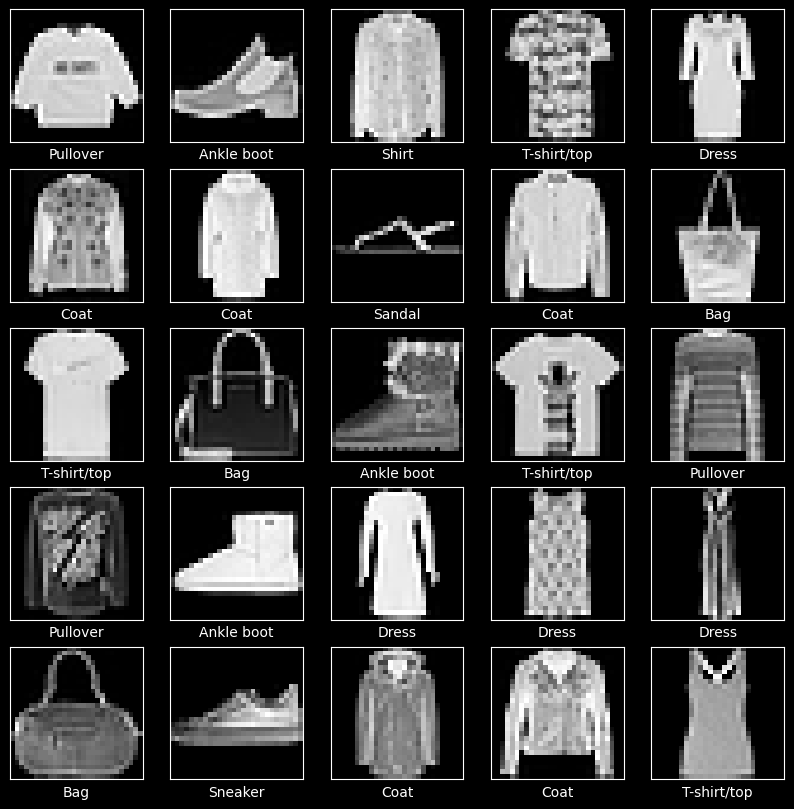

In [7]:
#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()


### Preprocessing output - converting to one hot categorical data (1D to 2D)

In [8]:
print(y_train_fashion.shape, y_test_fashion.shape)


(60000,) (10000,)


In [9]:
y_train_fashion = to_categorical(y_train_fashion, num_classes=10)
y_test_fashion = to_categorical(y_test_fashion, num_classes=10)
y_train_fashion


array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(60000, 10))

In [10]:
y_train_fashion[3]


array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

### Model creation

In [11]:
#Creating base neural network
model = keras.Sequential([
    layers.Dense(138, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),   # decreases accurace by 0.3 to make learning better again.
    layers.BatchNormalization(),     # normalize data for next layer
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10,activation='softmax'),
])
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])
history=model.fit(X_train_fashion, y_train_fashion, batch_size=100, epochs=30,validation_data=(X_test_fashion, y_test_fashion))


d:\HopeAI\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6320 - loss: 1.0779 - val_accuracy: 0.8134 - val_loss: 0.5366
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7504 - loss: 0.7271 - val_accuracy: 0.8395 - val_loss: 0.4706
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7738 - loss: 0.6640 - val_accuracy: 0.8470 - val_loss: 0.4564
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7858 - loss: 0.6280 - val_accuracy: 0.8227 - val_loss: 0.4951
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7939 - loss: 0.6049 - val_accuracy: 0.8544 - val_loss: 0.4400
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7979 - loss: 0.5948 - val_accuracy: 0.8489 - val_loss: 0.4289
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8047 - loss: 0.5769 - val_accuracy: 0.8615 - val_loss: 0.4154
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8069 - loss: 0.5722 - val_accuracy: 0.

In [12]:
# Parameters=input units × (output units + 1)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 138)            │       108,330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 138)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 138)            │           552 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,038 (1.29 MB)

 Trainable params: 112,888 (440.97 KB)

 Non-trainable params: 372 (1.45 KB)

 Optimizer params: 225,778 (881.95 KB)

In [13]:
test_loss_fashion, test_acc_fashion = model.evaluate(X_test_fashion, y_test_fashion)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8669 - loss: 0.3804


In [ ]:
print('Fashion MNIST Test accuracy:', round(test_acc_fashion,4))


Fashion MNIST Test accuracy: 0.8669


### Predicting 

In [18]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_fashion)
y_predicts=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_fashion_eval=np.argmax(y_test_fashion, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [19]:
# Predicted values reverse encoding
y_predicts


array([0, 1, 2, ..., 8, 8, 2], shape=(10000,))

### Visualising the Confusion Matrix using Heatmap

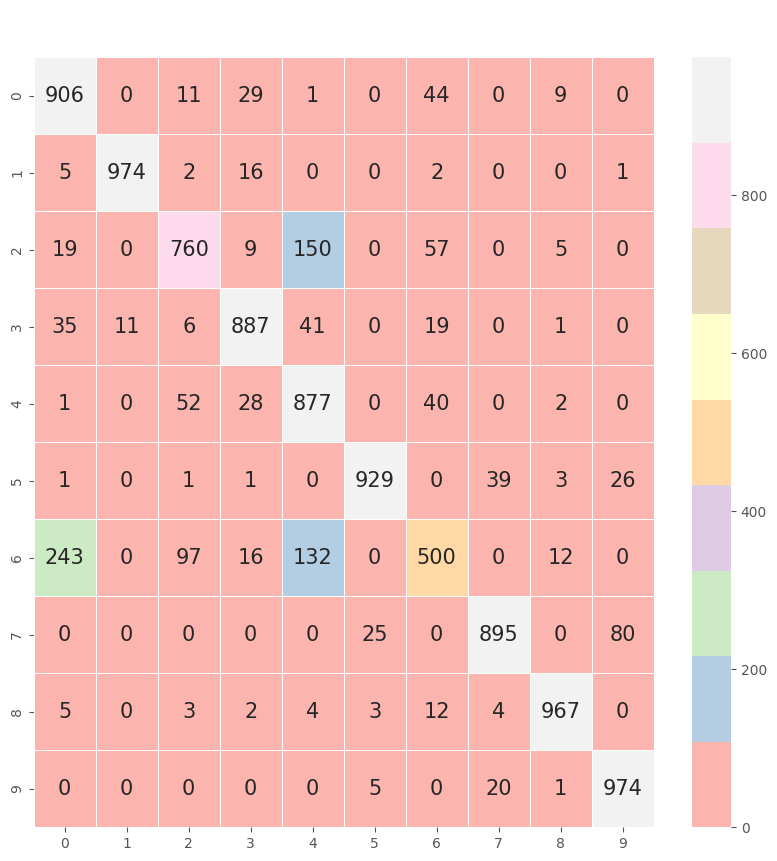

In [20]:
#Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_fashion_eval,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="Pastel1")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()


### Classification Report

In [21]:

print(classification_report(y_test_fashion_eval,y_predicts))


              precision    recall  f1-score   support

           0       0.75      0.91      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.82      0.76      0.79      1000
           3       0.90      0.89      0.89      1000
           4       0.73      0.88      0.80      1000
           5       0.97      0.93      0.95      1000
           6       0.74      0.50      0.60      1000
           7       0.93      0.90      0.91      1000
           8       0.97      0.97      0.97      1000
           9       0.90      0.97      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000



### Accuracy Plot

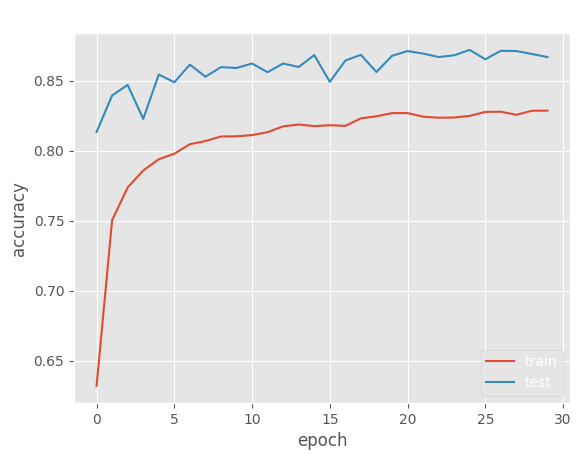

In [22]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


### Loss Plot

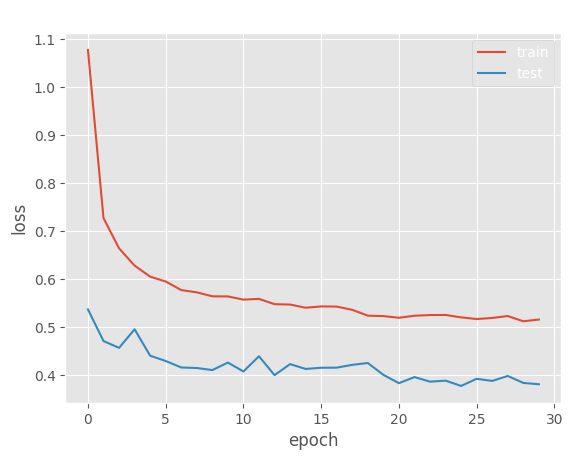

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


### Checking for single value

In [37]:
X_test_fashion.loc[[3],:]


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3,0,0,0,0,0,0,0,0,0,161,...,137,126,140,0,133,224,222,56,0,0


In [47]:
# Reverse encoding single value and 
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_fashion.loc[[10],:])
y_predicts_single=np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
# y_test_digit_eval=np.argmax(y_test_fashion, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [48]:
print(y_predict_single)
print('\n', y_predicts_single)


[[2.0521114e-02 7.3193708e-03 5.0258206e-04 9.6336967e-01 4.5421352e-03
  8.7498684e-06 3.5813632e-03 4.7795973e-05 7.6699362e-05 3.0522311e-05]]

 [3]


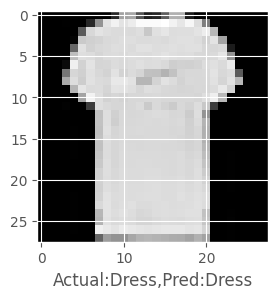

In [49]:
#Names of numbers in the dataset in order
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the digits
plt.figure(figsize=(3,3))
plt.imshow(x_train_reshape[10], cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_fashion[10])],col_names[y_predicts_single[0]]))
plt.show()


In [ ]:
y_test_digit_eval


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))